In [1]:
import torch, pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
import os

model_path = "../models/saved_model"

tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)



2025-10-15 21:14:34.099296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 21:14:34.138635: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-15 21:14:34.980273: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Load the same test set used during training
df_test = pd.read_csv("../data/splits/test.csv")

texts = df_test["text"].tolist()
labels = df_test["label"].tolist()

# Tokenize
test_encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=256  
)

# Wrap in Dataset class
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.labels)
        
# Create test dataset
test_dataset = EmailDataset(test_encodings, labels)



In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)   # Predicted class
    
    # Compute precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    # Compute overall accuracy
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
 

In [4]:
import optuna

# Construct absolute path to the database
db_path = os.path.join(os.getcwd(), "tuning_checkpoints", "bert_tuning.db")

# Load the Optuna study
study = optuna.load_study(
    study_name="bert_tuning",  # Load in the study
    storage=f"sqlite:///{db_path}" # Load from the DB file
)

# Get the best parameters and F1 value
best_params = study.best_params 
best_value = study.best_value

print("Best hyperparameters found:", best_params)
print(f"Best F1 score: {best_value:.4f}")

Best hyperparameters found: {'learning_rate': 5.1196576269375056e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16}
Best F1 score: 3.9864


In [5]:
# Load in using the best hyperparameter found
training_args = TrainingArguments(
    output_dir="./results_final", # Where to save model checkpoints & logs
    eval_strategy="epoch", # Evaluate model checkpoints after each epoch
    save_strategy="epoch", # Save model checkpoints after each epoch
    load_best_model_at_end=True, # Load the best model based on eval metric
    metric_for_best_model="f1",
    learning_rate=best_params["learning_rate"], # Set the learning rate to the best one it has found
    num_train_epochs=int(best_params["num_train_epochs"]), # Set the number of epochs to the best one it has found
    per_device_train_batch_size=int(best_params["per_device_train_batch_size"]), # Set the batch size to the best one it has found
    logging_dir="./logs_final",
)

# Create the Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [6]:
# Evaluate on test set
results = trainer.evaluate()
print("Test Results:", results)

# Save to JSON
with open("test_results.json", "w") as f:
    json.dump(results, f, indent=4)


Test Results: {'eval_loss': 0.23824626207351685, 'eval_model_preparation_time': 0.0023, 'eval_accuracy': 0.9565741252070887, 'eval_precision': 0.9520465489566613, 'eval_recall': 0.9608180621646248, 'eval_f1': 0.9564121945074326, 'eval_runtime': 105.1065, 'eval_samples_per_second': 189.513, 'eval_steps_per_second': 23.69}


{
  "Ham": {
    "precision": 0.9611094362375641,
    "recall": 0.9523999203345948,
    "f1-score": 0.95673485720002,
    "support": 10042.0
  },
  "Phishing": {
    "precision": 0.9520465489566613,
    "recall": 0.9608180621646248,
    "f1-score": 0.9564121945074326,
    "support": 9877.0
  },
  "accuracy": 0.9565741252070887,
  "macro avg": {
    "precision": 0.9565779925971127,
    "recall": 0.9566089912496099,
    "f1-score": 0.9565735258537263,
    "support": 19919.0
  },
  "weighted avg": {
    "precision": 0.9566155290296983,
    "recall": 0.9565741252070887,
    "f1-score": 0.956574862249737,
    "support": 19919.0
  }
}


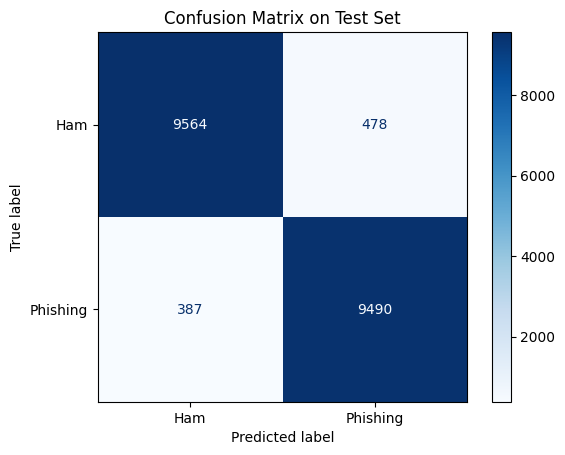

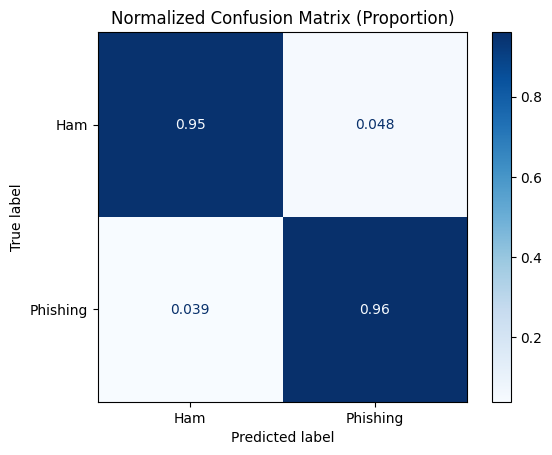

In [7]:
# Get predictions
preds_output = trainer.predict(test_dataset)
preds = preds_output.predictions.argmax(-1)
true_labels = preds_output.label_ids

# Classification report
report = classification_report(true_labels, preds, target_names=["Ham", "Phishing"], output_dict=True)
print(json.dumps(report, indent=2))

# Confusion matrices
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.savefig("../notebooks/confusion_matrix_raw.png", bbox_inches="tight", dpi=300) # Save figure
plt.show()

# Normalized version
cm_norm = confusion_matrix(true_labels, preds, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Ham", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Normalized Confusion Matrix (Proportion)")
plt.savefig("../notebooks/confusion_matrix_normalized.png", bbox_inches="tight", dpi=300) # Save normalized version of the confusion map
plt.show()
